# Proyek Akhir: Menyelesaikan Permasalahan Jaya Jaya Institut

- Nama: Aflaha Setyaningrum
- Email: setyaaflaha@gmail.com
- Id Dicoding: aflahasetyaningrum

## Persiapan
Jaya Jaya Institut menghadapi tingginya angka dropout siswa yang berdampak pada reputasi dan kualitas pendidikan.

Tujuan dari proyek ini adalah:
1. Mengidentifikasi faktor utama penyebab dropout
2. Membangun model prediksi
3. Memberikan rekomendasi berbasis data

### Menyiapkan library yang dibutuhkan

Pada tahap ini dilakukan import library yang digunakan untuk proses analisis data, visualisasi, preprocessing, serta pembuatan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data/students.csv', sep=';')
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Informasi dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

Dataset terdiri dari X baris dan Y kolom dengan beberapa tipe data seperti numerik dan kategorikal yang akan diproses lebih lanjut.

Statistik deskriptif

In [4]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Cek missing values

In [5]:
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


Tidak terdapat missing values / terdapat beberapa missing values pada kolom tertentu yang perlu ditangani pada tahap preprocessing.

## EDA (EXPLORATORY DATA ANALYSIS)

Distribusi Status Siswa

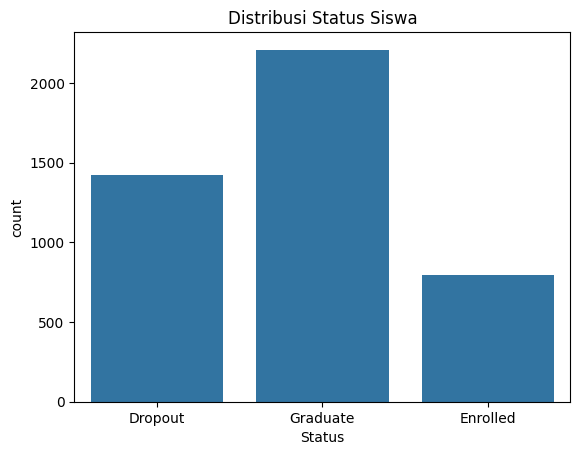

In [6]:
sns.countplot(x='Status', data=df)
plt.title("Distribusi Status Siswa")
plt.show()

Status vs Gender

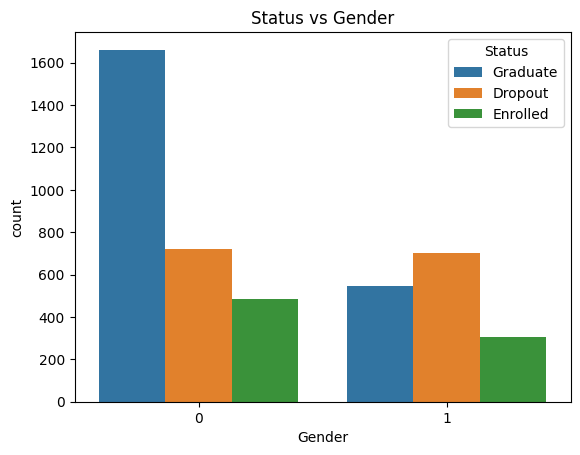

In [7]:
sns.countplot(x='Gender', hue='Status', data=df)
plt.title("Status vs Gender")
plt.show()

Status vs Scholarship

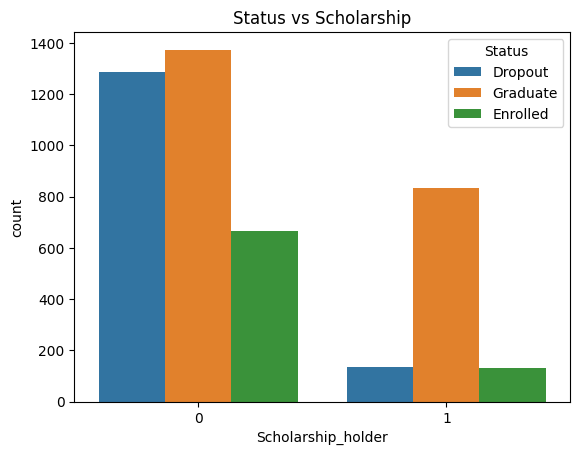

In [8]:
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title("Status vs Scholarship")
plt.show()

Umur vs Status

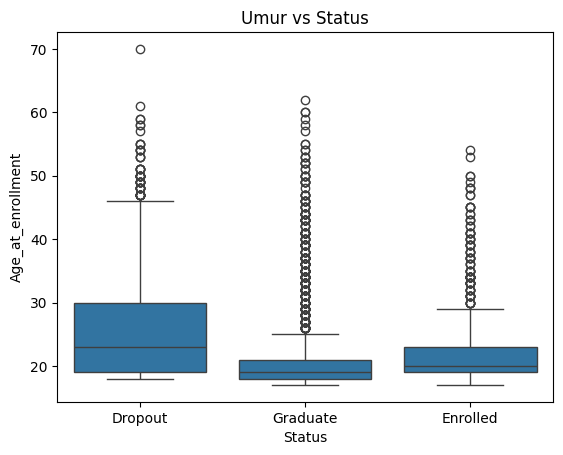

In [9]:
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title("Umur vs Status")
plt.show()

Korelasi antar fitur

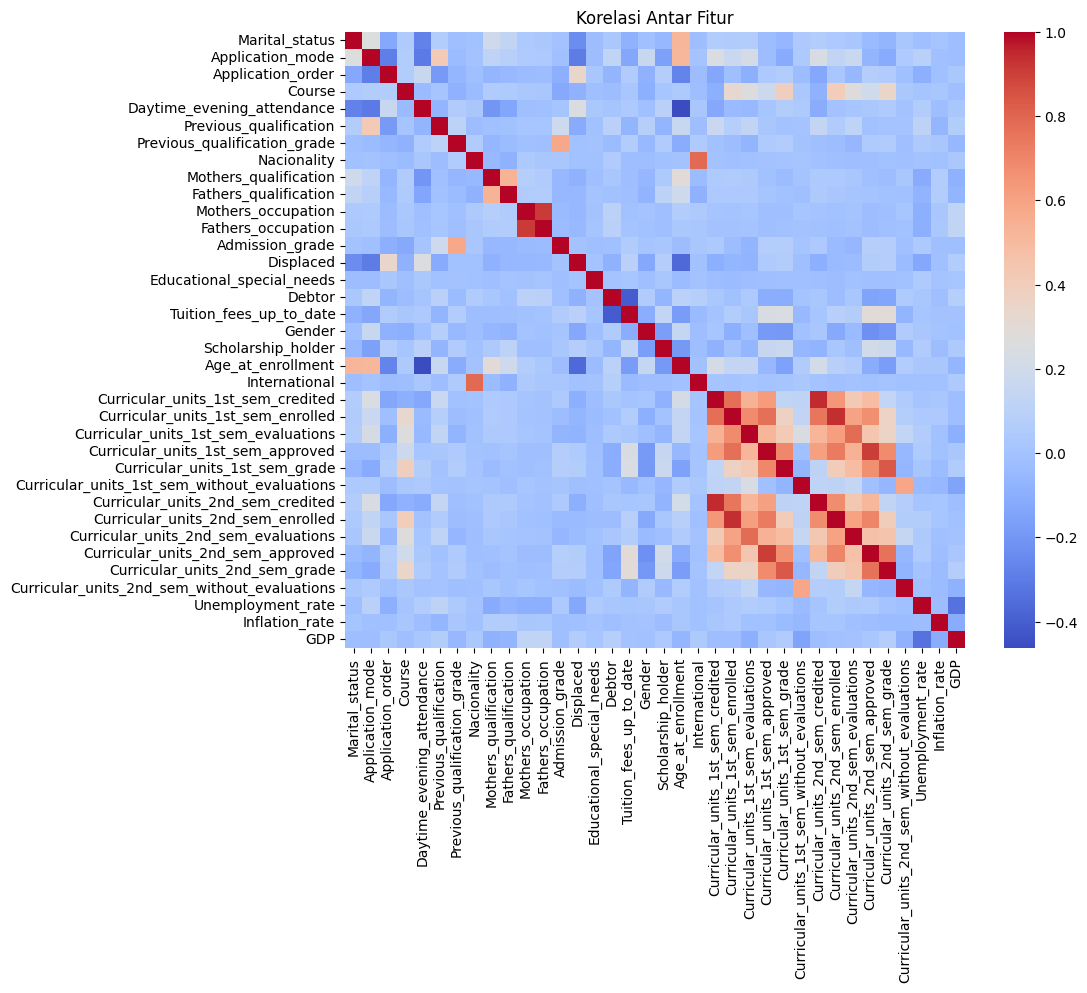

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title("Korelasi Antar Fitur")
plt.show()

## Data Preparation / Preprocessing

Filter hanya Dropout dan Graduate

In [11]:
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

Encode Target

In [12]:
df_model['Status'] = df_model['Status'].map({
    'Dropout': 0,
    'Graduate': 1
})

Memisahkan fitur & target

In [13]:
FEATURES = [
    'Age_at_enrollment',
    'Gender',
    'Scholarship_holder',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_enrolled',
]

X = df_model[FEATURES]
y = df_model['Status']

Handling categorical

In [14]:
X = pd.get_dummies(X, drop_first=True)

Scaling

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Split data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Modeling

Training Model

In [17]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation

Evaluasi model

In [18]:
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       277
           1       0.90      0.95      0.92       449

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.90      0.90      0.90       726



Confusion Matrix

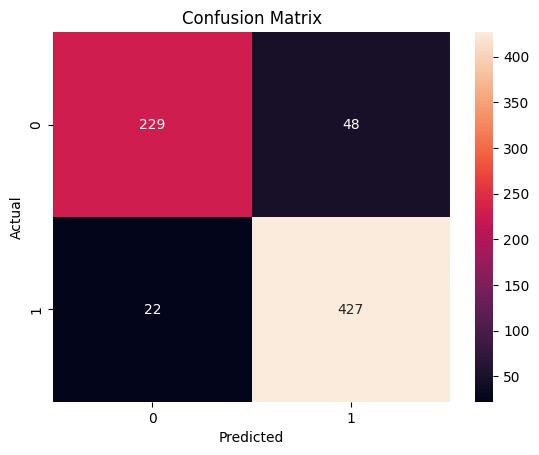

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

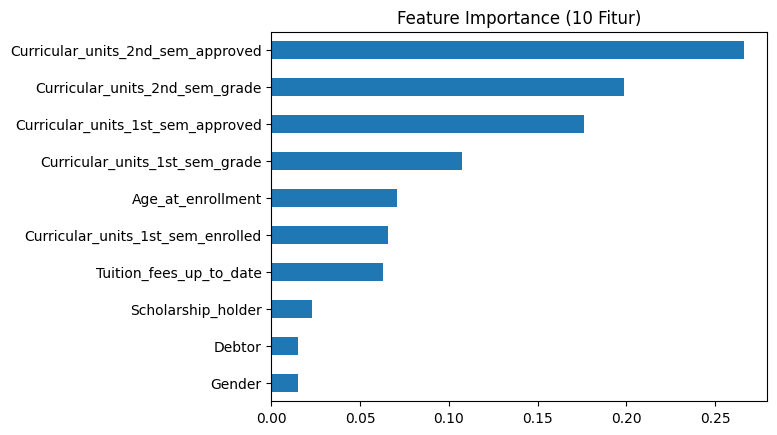

In [20]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh')
plt.title("Feature Importance (10 Fitur)")
plt.show()

In [21]:
import sys
!"{sys.executable}" -m pip install scikit-learn==1.7.2 numpy==2.4.4 pandas==3.0.2

In [22]:
import sys
print(sys.executable)

d:\Install Program\Anaconda\anaconda\envs\streamlit_env\python.exe


In [23]:
import sys, sklearn
print(sys.executable)
print(sklearn.__version__)

d:\Install Program\Anaconda\anaconda\envs\streamlit_env\python.exe
1.7.2


In [24]:
import pickle
import sklearn
import os

os.makedirs('model', exist_ok=True)

# Simpan model beserta versi sklearn
with open('model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('model/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(sklearn.__version__)

1.7.2


PREDIKSI DATA ENROLLED

Prediksi untuk siswa berstatus Enrolled

In [25]:
df_enrolled = df[df['Status'] == 'Enrolled'].copy()

X_enrolled = df_enrolled[FEATURES]
X_enrolled = pd.get_dummies(X_enrolled, drop_first=True)
X_enrolled = X_enrolled.reindex(columns=X.columns, fill_value=0)

X_enrolled_scaled = scaler.transform(X_enrolled)

df_enrolled['Prediction'] = model.predict(X_enrolled_scaled)
df_enrolled['Prediction'] = df_enrolled['Prediction'].map({0: 'Dropout', 1: 'Graduate'})

print(f"Total siswa Enrolled: {len(df_enrolled)}")
df_enrolled[['Prediction']].value_counts()

Total siswa Enrolled: 794


Prediction
Graduate      444
Dropout       350
Name: count, dtype: int64